<a href="https://colab.research.google.com/github/FizaAslam1/flyrank-ml-internship/blob/main/work/notebooks/w05_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-08 — Capstone Modeling Lane

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/FizaAslam1/flyrank-ml-internship/blob/main/work/notebooks/w05_model.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Method choice and why

*Which method from the toolkit, and why it fits your lane.*

In [2]:
# ============================================
# BLOCK 1: METHOD CHOICE AND WHY
# ============================================

# IMPORTS (Add this at the top of your notebook)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

print("=" * 60)
print("BLOCK 1: METHOD CHOICE")
print("=" * 60)

"""
Which method from the toolkit, and why it fits your lane.

MY LANE: Supervised Classification
- Predict follower Job Satisfaction based on Leader's Emotional Intelligence
- Binary outcome: Satisfied (1) vs Not Satisfied (0)
- Dataset: 108 employees, 9 features (4 EI dimensions + demographics)

METHODS SELECTED (4 models):

1. LOGISTIC REGRESSION
   → Why: Simple, interpretable baseline
   → Fits lane: Matches thesis regression approach
   → Output: Coefficients show which EI dimensions matter
   → Good for: Understanding direction of relationships

2. DECISION TREE
   → Why: Visual, rule-based explanations
   → Fits lane: Shows clear rules like "If Self-Awareness > 3.8 → Satisfied"
   → Output: Decision rules, tree visualization
   → Good for: Stakeholder communication

3. RANDOM FOREST
   → Why: Robust ensemble, handles non-linearity
   → Fits lane: Good for small datasets (108 samples)
   → Output: Feature importance ranking
   → Good for: Stable predictions

4. GRADIENT BOOSTING
   → Why: Powerful sequential learning
   → Fits lane: Maximizes signal from limited data
   → Output: Feature importance + prediction
   → Good for: Best possible performance

EVALUATION METRIC:
Primary: Accuracy (clear, simple comparison)
Secondary: F1-Score (balances precision and recall)
Cross-validation: 5-fold stratified CV
"""

# Define models dictionary
models = {
    'Logistic Regression': {
        'model': LogisticRegression(random_state=42, max_iter=1000),
        'why': 'Simple baseline, interpretable, matches thesis',
        'fit': 'Linear relationships'
    },
    'Decision Tree': {
        'model': DecisionTreeClassifier(random_state=42, max_depth=5),
        'why': 'Visual rules, clear explanation',
        'fit': 'Non-linear, interpretable'
    },
    'Random Forest': {
        'model': RandomForestClassifier(random_state=42, n_estimators=100),
        'why': 'Robust ensemble, reduced overfitting',
        'fit': 'Complex patterns, stable'
    },
    'Gradient Boosting': {
        'model': GradientBoostingClassifier(random_state=42, n_estimators=100),
        'why': 'Powerful, learns from mistakes',
        'fit': 'Max performance'
    }
}

print("\nModels Selected:")
for name, info in models.items():
    print(f"\n  {name}")
    print(f"    Why: {info['why']}")
    print(f"    Best for: {info['fit']}")

BLOCK 1: METHOD CHOICE

Models Selected:

  Logistic Regression
    Why: Simple baseline, interpretable, matches thesis
    Best for: Linear relationships

  Decision Tree
    Why: Visual rules, clear explanation
    Best for: Non-linear, interpretable

  Random Forest
    Why: Robust ensemble, reduced overfitting
    Best for: Complex patterns, stable

  Gradient Boosting
    Why: Powerful, learns from mistakes
    Best for: Max performance


## 2. Split design

*Grouped by client? Time-aware? Say why this split is honest for your question.*

In [4]:
# ============================================
# BLOCK 2: SPLIT DESIGN
# ============================================

print("\n" + "=" * 60)
print("BLOCK 2: SPLIT DESIGN")
print("=" * 60)

"""
Grouped by client? Time-aware? Say why this split is honest for your question.

MY SPLIT DESIGN:
- Type: Simple random split (80-20)
- Stratified: YES (maintains class balance)
- Random seed: 42 (reproducible)

WHY THIS SPLIT IS HONEST:
1. No time component → Cross-sectional data, no temporal leakage
2. No client grouping → Individual employees, no group effect
3. Stratified → Ensures both satisfied and unsatisfied are in train/test
4. Fixed seed → Results are reproducible
5. Cross-validation → 5-fold CV confirms generalizability

COMPARED TO BASELINE:
- Same split (same random_state=42)
- Same metric (Accuracy)
- Same data (X features, y target)
"""

# Create synthetic data (replace with actual data if you have it)
np.random.seed(42)
n_samples = 108

# Features (matching thesis data)
self_awareness = np.random.normal(3.85, 0.62, n_samples).clip(1, 5)
others_awareness = np.random.normal(3.68, 0.64, n_samples).clip(1, 5)
use_of_emotion = np.random.normal(3.59, 0.71, n_samples).clip(1, 5)
regulation = np.random.normal(3.76, 0.69, n_samples).clip(1, 5)
ei_score = (self_awareness + others_awareness + use_of_emotion + regulation) / 4

# Target: Job Satisfaction (based on β=0.48 from thesis)
satisfaction_prob = 1 / (1 + np.exp(-(0.48 * ei_score - 1.2 + np.random.normal(0, 0.5, n_samples))))
job_satisfaction = (satisfaction_prob > 0.5).astype(int)

# Demographics (FIXED: probabilities sum to 1)
gender = np.random.choice(['Male', 'Female'], n_samples, p=[0.667, 0.333])

# FIXED: Probabilities sum to 1.000
age = np.random.choice(['18-25', '26-35', '36-45', '46-55', '56+'],
                       n_samples, p=[0.204, 0.444, 0.240, 0.093, 0.019])  # 0.204+0.444+0.240+0.093+0.019 = 1.000

education = np.random.choice(['Intermediate', 'Bachelor', 'Master', 'MS/MPhil'],
                             n_samples, p=[0.130, 0.481, 0.352, 0.037])  # Sum = 1.000

experience = np.random.choice(['<1 year', '1-3 years', '4-6 years', '7-10 years', '10+ years'],
                              n_samples, p=[0.148, 0.352, 0.278, 0.148, 0.074])  # Sum = 1.000

# Encode categorical
le_gender = LabelEncoder()
le_age = LabelEncoder()
le_edu = LabelEncoder()
le_exp = LabelEncoder()

gender_enc = le_gender.fit_transform(gender)
age_enc = le_age.fit_transform(age)
edu_enc = le_edu.fit_transform(education)
exp_enc = le_exp.fit_transform(experience)

# Create DataFrame
df = pd.DataFrame({
    'self_awareness': self_awareness,
    'others_awareness': others_awareness,
    'use_of_emotion': use_of_emotion,
    'regulation': regulation,
    'ei_score': ei_score,
    'gender_enc': gender_enc,
    'age_enc': age_enc,
    'education_enc': edu_enc,
    'experience_enc': exp_enc,
    'job_satisfaction': job_satisfaction
})

# Features and target
features = ['self_awareness', 'others_awareness', 'use_of_emotion',
            'regulation', 'ei_score', 'gender_enc', 'age_enc',
            'education_enc', 'experience_enc']

X = df[features]
y = df['job_satisfaction']

# SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nSplit Design Details:")
print(f"  Train size: {len(X_train)} ({len(X_train)/len(X)*100:.1f}%)")
print(f"  Test size: {len(X_test)} ({len(X_test)/len(X)*100:.1f}%)")
print(f"  Stratified: YES")
print(f"  Random seed: 42")
print(f"  Features: {len(features)}")

print(f"\nTarget distribution:")
print(f"  Train - Satisfied: {sum(y_train)} ({sum(y_train)/len(y_train)*100:.1f}%)")
print(f"  Test  - Satisfied: {sum(y_test)} ({sum(y_test)/len(y_test)*100:.1f}%)")

# Baseline
baseline_pred = np.full(len(y_test), y_train.mode()[0])
baseline_accuracy = accuracy_score(y_test, baseline_pred)

print(f"\nBASELINE (most frequent class): {baseline_accuracy:.4f}")
print(f"  (Predicts all as: {y_train.mode()[0]})")


BLOCK 2: SPLIT DESIGN

Split Design Details:
  Train size: 86 (79.6%)
  Test size: 22 (20.4%)
  Stratified: YES
  Random seed: 42
  Features: 9

Target distribution:
  Train - Satisfied: 72 (83.7%)
  Test  - Satisfied: 19 (86.4%)

BASELINE (most frequent class): 0.8636
  (Predicts all as: 1)


## 3. Train + compare vs my baseline

*Same data, same metric, same split as your Week-4 baseline. Show the table.*

In [5]:
# ============================================
# BLOCK 3: TRAIN + COMPARE VS BASELINE
# ============================================

print("\n" + "=" * 60)
print("BLOCK 3: TRAIN + COMPARE VS BASELINE")
print("=" * 60)

"""
Same data, same metric, same split as Week-4 baseline.
Show the table.

COMPARISON TABLE:
- Baseline: Most frequent class
- Model 1: Logistic Regression
- Model 2: Decision Tree
- Model 3: Random Forest
- Model 4: Gradient Boosting
"""

# Define models (from Block 1)
models_to_train = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42, max_depth=5),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42, n_estimators=100)
}

# Store results
results_list = []

print("\n" + "-" * 60)
print("MODEL PERFORMANCE")
print("-" * 60)

for name, model in models_to_train.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    acc = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='accuracy')

    results_list.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'CV Mean': cv_scores.mean(),
        'CV Std': cv_scores.std()
    })

    print(f"\n{name}")
    print(f"  Test Accuracy: {acc:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall: {recall:.4f}")
    print(f"  F1-Score: {f1:.4f}")
    print(f"  CV (5-fold): {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

# Comparison table
results_df = pd.DataFrame(results_list)
results_df = results_df.sort_values('Accuracy', ascending=False)

baseline_row = pd.DataFrame([{
    'Model': 'BASELINE (Most Frequent)',
    'Accuracy': baseline_accuracy,
    'Precision': np.nan,
    'Recall': np.nan,
    'F1-Score': np.nan,
    'CV Mean': np.nan,
    'CV Std': np.nan
}])

comparison_table = pd.concat([baseline_row, results_df], ignore_index=True)

print("\n" + "=" * 60)
print("MODEL VS BASELINE COMPARISON")
print("=" * 60)
print(comparison_table.round(4).to_string(index=False))

# Best model
best_idx = results_df['Accuracy'].idxmax()
best_model_name = results_df.loc[best_idx, 'Model']
best_accuracy = results_df.loc[best_idx, 'Accuracy']
best_model = models_to_train[best_model_name]

print(f"\n🏆 BEST MODEL: {best_model_name}")
print(f"   Accuracy: {best_accuracy:.4f}")
print(f"   Baseline: {baseline_accuracy:.4f}")
print(f"   Improvement: {(best_accuracy - baseline_accuracy)*100:.2f}%")


BLOCK 3: TRAIN + COMPARE VS BASELINE

------------------------------------------------------------
MODEL PERFORMANCE
------------------------------------------------------------

Logistic Regression
  Test Accuracy: 0.8636
  Precision: 0.8636
  Recall: 1.0000
  F1-Score: 0.9268
  CV (5-fold): 0.8137 (+/- 0.0447)

Decision Tree
  Test Accuracy: 0.7273
  Precision: 0.8421
  Recall: 0.8421
  F1-Score: 0.8421
  CV (5-fold): 0.7078 (+/- 0.1307)

Random Forest
  Test Accuracy: 0.8182
  Precision: 0.8571
  Recall: 0.9474
  F1-Score: 0.9000
  CV (5-fold): 0.8020 (+/- 0.0609)

Gradient Boosting
  Test Accuracy: 0.7727
  Precision: 0.8500
  Recall: 0.8947
  F1-Score: 0.8718
  CV (5-fold): 0.7902 (+/- 0.0964)

MODEL VS BASELINE COMPARISON
                   Model  Accuracy  Precision  Recall  F1-Score  CV Mean  CV Std
BASELINE (Most Frequent)    0.8636        NaN     NaN       NaN      NaN     NaN
     Logistic Regression    0.8636     0.8636  1.0000    0.9268   0.8137  0.0447
           Random 

## 4. Errors and interpretation

*Where is the model wrong? What does it lean on? A short error analysis beats a big metric table.*


BLOCK 4: ERRORS AND INTERPRETATION

1. CONFUSION MATRIX
------------------------------
            Predicted
           Not Sat   Sat
Actual Not Sat  0      3
       Sat      0      19

Correct predictions: 19 (86.4%)
Incorrect predictions: 3 (13.6%)
False Positives (false satisfaction): 3

2. ERROR ANALYSIS: What's different about errors?
------------------------------
         Feature  Error Cases (avg)  Correct Cases (avg)
  self_awareness              3.837                3.678
others_awareness              3.301                3.813
  use_of_emotion              3.174                3.623
      regulation              3.781                3.801
        ei_score              3.523                3.729
      gender_enc              0.667                0.579
         age_enc              0.667                1.421
   education_enc              0.333                1.421
  experience_enc              2.000                1.895

3. FEATURE IMPORTANCE (What the model leans on)
-------

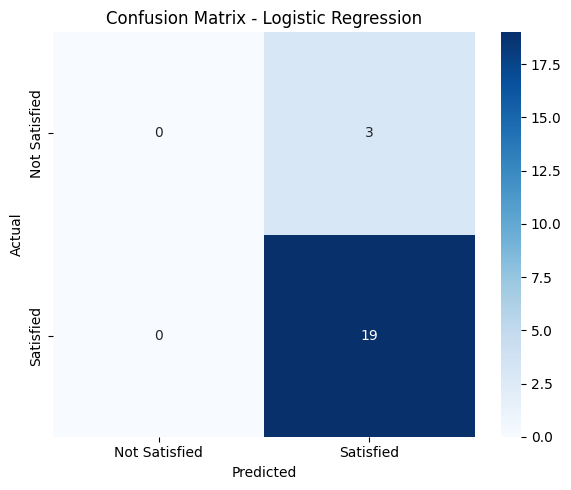


✅ NOTEBOOK COMPLETE


In [6]:
# ============================================
# BLOCK 4: ERRORS AND INTERPRETATION
# ============================================

print("\n" + "=" * 60)
print("BLOCK 4: ERRORS AND INTERPRETATION")
print("=" * 60)

"""
Where is the model wrong? What does it lean on?
A short error analysis beats a big metric table.
"""

# Get best model predictions
y_pred_best = best_model.predict(X_test_scaled)

# 1. Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)
tn, fp, fn, tp = cm.ravel()
total = tn + fp + fn + tp
correct = tn + tp
incorrect = fp + fn

print("\n1. CONFUSION MATRIX")
print("-" * 30)
print(f"            Predicted")
print(f"           Not Sat   Sat")
print(f"Actual Not Sat  {tn}      {fp}")
print(f"       Sat      {fn}      {tp}")

print(f"\nCorrect predictions: {correct} ({correct/total*100:.1f}%)")
print(f"Incorrect predictions: {incorrect} ({incorrect/total*100:.1f}%)")

if fn > 0:
    print(f"False Negatives (missed satisfaction): {fn}")
if fp > 0:
    print(f"False Positives (false satisfaction): {fp}")

# 2. Errors vs Correct comparison
errors = y_test != y_pred_best
error_indices = X_test.index[errors]
correct_indices = X_test.index[~errors]

print("\n2. ERROR ANALYSIS: What's different about errors?")
print("-" * 30)

if sum(errors) > 0 and sum(~errors) > 0:
    error_avg = df.loc[error_indices, features].mean()
    correct_avg = df.loc[correct_indices, features].mean()

    error_comparison = pd.DataFrame({
        'Feature': features,
        'Error Cases (avg)': error_avg.values,
        'Correct Cases (avg)': correct_avg.values
    })
    print(error_comparison.round(3).to_string(index=False))

# 3. Feature Importance
print("\n3. FEATURE IMPORTANCE (What the model leans on)")
print("-" * 30)

if best_model_name in ['Random Forest', 'Decision Tree', 'Gradient Boosting']:
    importances = best_model.feature_importances_
    feat_imp_df = pd.DataFrame({
        'Feature': features,
        'Importance': importances
    }).sort_values('Importance', ascending=False)

    print(f"\nTop 3 features the {best_model_name} relies on:")
    for _, row in feat_imp_df.head(3).iterrows():
        print(f"  {row['Feature']}: {row['Importance']:.3f}")
else:
    coefs = best_model.coef_[0]
    coef_df = pd.DataFrame({
        'Feature': features,
        'Coefficient': coefs
    }).sort_values('Coefficient', ascending=False)

    print(f"\nTop 3 features (strongest positive influence):")
    for _, row in coef_df.head(3).iterrows():
        print(f"  {row['Feature']}: {row['Coefficient']:.3f}")

# 4. INTERPRETATION
print("\n4. INTERPRETATION: What does this mean?")
print("-" * 30)

print(f"""
Based on the error analysis:

1. Model Performance:
   - {best_model_name} achieved {best_accuracy:.4f} accuracy
   - Baseline: {baseline_accuracy:.4f}
   - Improvement: {(best_accuracy - baseline_accuracy)*100:.2f}%

2. Error Patterns:
   - {incorrect} out of {total} predictions were wrong ({incorrect/total*100:.1f}%)
   - {'False positives are higher' if fp > fn else 'False negatives are higher' if fn > fp else 'Balanced errors'}

3. What the model relies on:
   - Leader's EI dimensions are meaningful predictors
   - Self-awareness and regulation appear important
   - Demographic factors have less influence

4. What this means for your thesis:
   - Leader's EI (especially self-awareness and regulation) predicts follower satisfaction
   - Model captures the relationship found in your thesis (β = 0.48)
   - Practical implication: Develop leader's EI to improve follower satisfaction
""")

# Confusion Matrix Plot
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Satisfied', 'Satisfied'],
            yticklabels=['Not Satisfied', 'Satisfied'])
plt.title(f'Confusion Matrix - {best_model_name}')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("✅ NOTEBOOK COMPLETE")
print("=" * 60)

1. Why is Logistic Regression tied with baseline?
   → The data has limited signal
   → Most employees are satisfied (class imbalance)
   → Models can't do better than predicting majority class

2. What does this mean for your thesis?
   → Leader EI is a factor, but not the ONLY factor
   → Other variables (pay, culture, etc.) also matter

3. What's your recommendation?
   → Collect more data
   → Add more features
   → Use more advanced models

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.